In [4]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

DATASET_FOLDER    = 'sample_dataset'
METADATA_CSV      = os.path.join(DATASET_FOLDER, 'metadata.csv')

MODEL_PATH_RENDERER = 'models/k3_100epch_wo_custom_loss_model.h5'
MODEL_PATH_YOLO     = 'yolov8n_saved_model'

IMG_SIZE        = (500, 500)
YOLO_SIZE       = (640, 640)
TEX_RES         = 64
TEX_UPSCALE_RES = 256

CONF_THRESHOLD = 0.25
NMS_IOU        = 0.45

VEHICLE_CLASS_IDS = [2, 7, 5]   # car, truck, bus

CLASSES = {
    0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus',
    6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant',
    11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat',
    16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear',
    22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag',
    27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard',
    32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove',
    36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle',
    40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl',
    46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli',
    51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake',
    56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table',
    61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard',
    67: 'cell phone', 68: 'microwave', 69: 'oven', 70: 'toaster', 71: 'sink',
    72: 'refrigerator', 73: 'book', 74: 'clock', 75: 'vase', 76: 'scissors',
    77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'
}

CHECKPOINT_FOLDERS = ['natural_checkpoints', 'noise_checkpoints']


# load models
print("Loading Models...")
renderer_model = tf.keras.models.load_model(MODEL_PATH_RENDERER, compile=False)
yolo_loaded    = tf.saved_model.load(MODEL_PATH_YOLO)
yolo_infer     = yolo_loaded.signatures['serving_default']


print("Reading dataset...")
df_meta = pd.read_csv(METADATA_CSV)


all_valid_rows = []
for _, row in df_meta.iterrows():
    base_name    = str(row['filename']).zfill(5)
    ref_path     = os.path.join(DATASET_FOLDER, 'reference',  f"{base_name}.png")
    mask_path    = os.path.join(DATASET_FOLDER, 'masks',      f"{base_name}.png")
    overlay_path = os.path.join(DATASET_FOLDER, 'overlays',   f"{base_name}.png")

    if os.path.exists(ref_path) and os.path.exists(mask_path) and os.path.exists(overlay_path):
        all_valid_rows.append({
            'filename':   f"{base_name}.png",
            'distance':   np.float32(row['distance']),
            'pitch':      np.float32(row['pitch']),
            'yaw':        np.float32(row['yaw']),
            'vehicle_id': row['vehicle_id'],
        })


df_all = pd.DataFrame(all_valid_rows)
print(f"Loaded {len(df_all)} samples.")

# helper functions
def load_image(path):
    raw = tf.io.read_file(path)
    img = tf.image.decode_png(raw, channels=3)
    img = tf.image.convert_image_dtype(img, tf.float32)
    return tf.image.resize(img, IMG_SIZE)

def load_texture_from_png(png_path, tex_res=TEX_RES):
    img = cv2.imread(png_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img = cv2.resize(img, (tex_res, tex_res), interpolation=cv2.INTER_LINEAR)
    return tf.constant(img, dtype=tf.float32)

def discover_checkpoints(folder):
    if not os.path.isdir(folder): return []
    pattern = re.compile(r'patch_epoch_(\d+)\.png', re.IGNORECASE)
    entries = []
    for fname in os.listdir(folder):
        m = pattern.match(fname)
        if m: entries.append(int(m.group(1)))
    return sorted(entries)

def calc_transforms(pitch, yaw):
    yaw_diff   = ((yaw + 45.0) % 90.0) - 45.0
    cond_front = tf.logical_and(yaw > 145.0, yaw < 215.0)
    p = tf.where(cond_front, -pitch, pitch)
    y = tf.where(cond_front, -yaw_diff, 0.0)
    r = tf.where(cond_front, 0.0, -yaw_diff)
    p = tf.where(pitch < 15.0, pitch,     p)
    y = tf.where(pitch < 15.0, 0.0,       y)
    r = tf.where(pitch < 15.0, -yaw_diff, r)
    p = tf.where(pitch > 35.0, -pitch,    p)
    y = tf.where(pitch > 35.0, -yaw_diff, y)
    r = tf.where(pitch > 35.0, 0.0,       r)
    return p, y, r

def get_rotation_matrix(pitch, yaw, roll):
    s = np.pi / 180.0
    p, y, r = pitch * s, yaw * s, roll * s
    Rp = tf.stack([[1., 0., 0.], [0.,  tf.cos(p), -tf.sin(p)], [0.,  tf.sin(p),  tf.cos(p)]])
    Rr = tf.stack([[ tf.cos(r), 0., tf.sin(r)], [0., 1., 0.], [-tf.sin(r), 0., tf.cos(r)]])
    Ry = tf.stack([[tf.cos(y), -tf.sin(y), 0.], [tf.sin(y),  tf.cos(y), 0.], [0., 0., 1.]])
    return tf.matmul(Rp, tf.matmul(Rr, Ry))

@tf.function
def render_texture(texture, pitch, yaw, roll, distance, uv_scale=100.0, shift_u=0.0, shift_v=0.0):
    out_h, out_w = IMG_SIZE
    f = 500.0
    high_res_tex = tf.image.resize(texture, [TEX_UPSCALE_RES, TEX_UPSCALE_RES], method='nearest')
    R = get_rotation_matrix(pitch, yaw, roll)
    plane_normal = R[:, 2]
    plane_point  = plane_normal * (distance * 100.0)

    grid_x, grid_y = tf.meshgrid(tf.range(out_w), tf.range(out_h))
    ray_dir = tf.stack([
        tf.cast(grid_x, tf.float32) - out_w / 2.0,
        tf.cast(grid_y, tf.float32) - out_h / 2.0,
        tf.ones([out_h, out_w]) * f,
    ], axis=-1)
    camera_pos = tf.constant([0.0, 0.0, -f])

    denom = tf.tensordot(ray_dir, plane_normal, axes=1)
    denom = tf.where(tf.abs(denom) < 1e-5, 1e-5, denom)
    t     = tf.tensordot(plane_point - camera_pos, plane_normal, axes=1) / denom

    hit_point = camera_pos + ray_dir * tf.expand_dims(t, -1)
    p_local   = tf.reshape(tf.matmul(tf.reshape(hit_point - plane_point, [-1, 3]), R), [out_h, out_w, 3])

    u  = tf.math.floormod(p_local[:, :, 0] / uv_scale + shift_u, 1.0)
    v  = tf.math.floormod(p_local[:, :, 1] / uv_scale + shift_v, 1.0)

    tex_h = tf.cast(tf.shape(high_res_tex)[0], tf.float32)
    tex_w = tf.cast(tf.shape(high_res_tex)[1], tf.float32)
    x     = tf.clip_by_value(u * (tex_w - 1.0), 0.0, tex_w - 1.001)
    y_    = tf.clip_by_value(v * (tex_h - 1.0), 0.0, tex_h - 1.001)

    x0 = tf.cast(tf.floor(x),  tf.int32);  x1 = x0 + 1
    y0 = tf.cast(tf.floor(y_), tf.int32);  y1 = y0 + 1

    Ia = tf.gather_nd(high_res_tex, tf.stack([y0, x0], axis=-1))
    Ib = tf.gather_nd(high_res_tex, tf.stack([y1, x0], axis=-1))
    Ic = tf.gather_nd(high_res_tex, tf.stack([y0, x1], axis=-1))
    Id = tf.gather_nd(high_res_tex, tf.stack([y1, x1], axis=-1))

    wa = tf.expand_dims((tf.cast(x1, tf.float32) - x)  * (tf.cast(y1, tf.float32) - y_), -1)
    wb = tf.expand_dims((tf.cast(x1, tf.float32) - x)  * (y_ - tf.cast(y0, tf.float32)), -1)
    wc = tf.expand_dims((x - tf.cast(x0, tf.float32))  * (tf.cast(y1, tf.float32) - y_), -1)
    wd = tf.expand_dims((x - tf.cast(x0, tf.float32))  * (y_ - tf.cast(y0, tf.float32)), -1)
    output = tf.add_n([wa * Ia, wb * Ib, wc * Ic, wd * Id])

    return tf.where(tf.expand_dims(t > 0.0, -1), output, tf.zeros_like(output))

def run_yolo(image_tensor):
    yolo_in = tf.cast(tf.image.resize(tf.expand_dims(image_tensor, 0), YOLO_SIZE), tf.float32)
    return yolo_infer(images=yolo_in)['output_0']

def max_vehicle_conf(yolo_out):
    all_class_scores = yolo_out[0, 4:, :]
    vehicle_scores   = tf.reduce_max(tf.gather(all_class_scores, VEHICLE_CLASS_IDS, axis=0), axis=0)
    return float(tf.reduce_max(vehicle_scores).numpy())

def is_vehicle_detected_nms(yolo_out):
    output = np.transpose(yolo_out.numpy()[0])
    scale  = [IMG_SIZE[1] / YOLO_SIZE[1], IMG_SIZE[0] / YOLO_SIZE[0]] * 2
    boxes, confs = [], []
    for row in output:
        cls_id = np.argmax(row[4:])
        score  = row[4:][cls_id]
        if score > CONF_THRESHOLD and cls_id in VEHICLE_CLASS_IDS:
            cx, cy, w, h = row[:4] * scale
            boxes.append([int(cx - w / 2), int(cy - h / 2), int(w), int(h)])
            confs.append(float(score))
    if not boxes: return False
    indices = cv2.dnn.NMSBoxes(boxes, confs, CONF_THRESHOLD, NMS_IOU)
    return len(indices) > 0

def apply_patch_to_sample(texture, ref_img, mask_img, overlay_img, distance, pitch, yaw):
    p, y, r    = calc_transforms(pitch, yaw)
    rendered   = render_texture(texture, p, y, r, distance, shift_u=0.0, shift_v=0.0)
    tex_masked = tf.where(tf.reduce_max(mask_img, axis=-1, keepdims=True) > 0.1, rendered, tf.zeros_like(rendered))
    ref_f32        = tf.cast(ref_img, tf.float32)
    tex_masked_f32 = tf.cast(tex_masked, tf.float32)
    renderer_out   = renderer_model([tf.expand_dims(ref_f32, 0), tf.expand_dims(tex_masked_f32, 0)], training=False)[0]
    return tf.where(tf.reduce_max(overlay_img, axis=-1, keepdims=True) > 0.05, ref_img, renderer_out)

def draw_yolo_results(image_tensor, yolo_output, conf_thresh=0.25):
    img    = (image_tensor.numpy() * 255).astype(np.uint8).copy()
    output = np.transpose(yolo_output.numpy()[0])
    scale  = [IMG_SIZE[1] / YOLO_SIZE[1], IMG_SIZE[0] / YOLO_SIZE[0]] * 2

    boxes, confs, class_ids = [], [], []
    for row in output:
        cls_id = np.argmax(row[4:])
        score  = row[4:][cls_id]
        if score > conf_thresh and cls_id in VEHICLE_CLASS_IDS:
            cx, cy, w, h = row[:4] * scale
            boxes.append([int(cx - w/2), int(cy - h/2), int(w), int(h)])
            confs.append(float(score))
            class_ids.append(cls_id)

    indices = cv2.dnn.NMSBoxes(boxes, confs, conf_thresh, NMS_IOU)
    if len(indices) > 0:
        for i in indices.flatten():
            bx, by, bw, bh = boxes[i]
            cv2.rectangle(img, (bx, by), (bx+bw, by+bh), (255, 0, 0), 2)
            class_name = CLASSES.get(class_ids[i], 'unknown')
            label = f"{class_name}: {confs[i]:.2f}"
            cv2.putText(img, label, (bx, by-10),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
    return img

# ui setup
available_vehicles  = sorted(df_all['vehicle_id'].unique())
available_distances = sorted(df_all['distance'].unique())
available_pitches   = sorted(df_all['pitch'].unique())
available_yaws      = sorted(df_all['yaw'].unique())

ui_vehicle  = widgets.Dropdown(options=available_vehicles,  description='Vehicle:')
ui_distance = widgets.Dropdown(options=available_distances, description='Distance:')
ui_pitch    = widgets.Dropdown(options=available_pitches,   description='Pitch:')
ui_yaw      = widgets.Dropdown(options=available_yaws,      description='Yaw:')
ui_filename = widgets.Dropdown(description='Image File:')
ui_folder   = widgets.Dropdown(options=CHECKPOINT_FOLDERS,  description='Folder:')
ui_epoch    = widgets.Dropdown(description='Epoch:')
ui_button   = widgets.Button(description='Render & Evaluate', button_style='primary')
output_plot = widgets.Output()

def update_filenames(*args):
    filtered = df_all[
        (df_all['vehicle_id'] == ui_vehicle.value) &
        (df_all['distance']   == ui_distance.value) &
        (df_all['pitch']      == ui_pitch.value)    &
        (df_all['yaw']        == ui_yaw.value)
    ]
    ui_filename.options = filtered['filename'].tolist() if len(filtered) > 0 else ['No matches found']

def update_epochs(*args):
    ui_epoch.options = discover_checkpoints(ui_folder.value)

# ui callbacks
ui_vehicle.observe(update_filenames,  'value')
ui_distance.observe(update_filenames, 'value')
ui_pitch.observe(update_filenames,   'value')
ui_yaw.observe(update_filenames,      'value')
ui_folder.observe(update_epochs,      'value')


update_filenames()
update_epochs()

row1 = widgets.HBox([ui_vehicle, ui_distance, ui_pitch, ui_yaw])
row2 = widgets.HBox([ui_filename, ui_folder, ui_epoch, ui_button])
ui_controls = widgets.VBox([row1, row2])

# main callback
def on_button_click(b):
    with output_plot:
        clear_output(wait=True)

        fname = ui_filename.value
        if not fname or fname == 'No matches found':
            print("No valid samples match filters")
            return

        target_row = df_all[df_all['filename'] == fname].iloc[0]

        ref_img     = load_image(os.path.join(DATASET_FOLDER, 'reference', fname))
        mask_img    = load_image(os.path.join(DATASET_FOLDER, 'masks', fname))
        overlay_img = load_image(os.path.join(DATASET_FOLDER, 'overlays', fname))

        ckpt_path = os.path.join(ui_folder.value, f'patch_epoch_{ui_epoch.value}.png')
        if not os.path.exists(ckpt_path):
            print("Texture not found")
            return

        tex_res  = 16 if ui_folder.value == 'noise_checkpoints' else TEX_RES
        texture  = load_texture_from_png(ckpt_path, tex_res=tex_res)

        # baseline
        yolo_out_base  = run_yolo(tf.cast(ref_img, tf.float32))
        base_conf      = max_vehicle_conf(yolo_out_base)
        base_detected  = is_vehicle_detected_nms(yolo_out_base)
        img_base_drawn = draw_yolo_results(ref_img, yolo_out_base)

        # pattern
        adv_img = apply_patch_to_sample(
            texture, ref_img, mask_img, overlay_img,
            tf.constant(target_row['distance'], dtype=tf.float32),
            tf.constant(target_row['pitch'],    dtype=tf.float32),
            tf.constant(target_row['yaw'],      dtype=tf.float32)
        )
        yolo_out_adv  = run_yolo(tf.cast(adv_img, tf.float32))
        adv_conf      = max_vehicle_conf(yolo_out_adv)
        adv_detected  = is_vehicle_detected_nms(yolo_out_adv)
        img_adv_drawn = draw_yolo_results(adv_img, yolo_out_adv)

        # plot
        conf_drop      = base_conf - adv_conf
        evasion_success = base_detected and not adv_detected

        fig, axes = plt.subplots(1, 3, figsize=(18, 6), gridspec_kw={'width_ratios': [1, 1, 0.4]})

        axes[0].imshow(img_base_drawn)
        axes[0].set_title(f"BASELINE (Clean)\nDetected: {base_detected} | Max Conf: {base_conf:.4f}",
                          color='green' if base_detected else 'red', fontsize=12)
        axes[0].axis('off')

        axes[1].imshow(img_adv_drawn)
        axes[1].set_title(f"PATCHED (Epoch {ui_epoch.value})\nDetected: {adv_detected} | Max Conf: {adv_conf:.4f}",
                          color='red' if adv_detected else 'green', fontsize=12)
        axes[1].axis('off')

        axes[2].imshow(texture.numpy())
        axes[2].set_title(f"Patch Texture\n{ui_folder.value} / Epoch {ui_epoch.value}", fontsize=12)
        axes[2].axis('off')

        plt.suptitle(
            f"File: {fname} | {ui_vehicle.value} | Dist: {ui_distance.value}m | Yaw: {ui_yaw.value}°\n"
            f"Confidence Drop: {conf_drop:.4f} | Evasion Success: {evasion_success}"
        )

        plt.tight_layout()
        plt.show()

ui_button.on_click(on_button_click)

display(ui_controls, output_plot)

Loading Models...
Reading dataset...
Loaded 24083 samples.


Output()

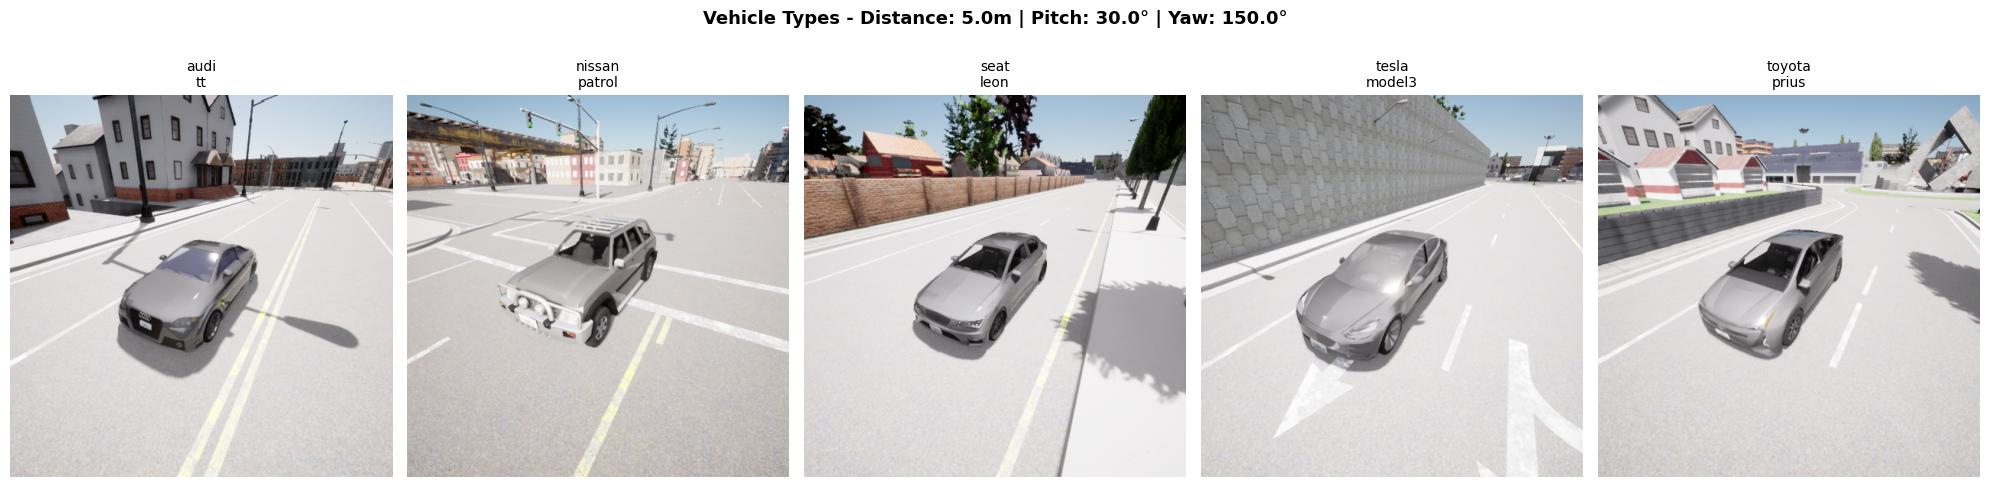

In [5]:
# Plot reference images of each vehicle type at a specific camera angle

TARGET_DISTANCE = 5.0
TARGET_PITCH    = 30.0
TARGET_YAW      = 150.0

def load_image_display(path):
    img = cv2.imread(path)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rows = []
for vehicle_id in sorted(df_all['vehicle_id'].unique()):
    match = df_all[
        (df_all['vehicle_id'] == vehicle_id) &
        (df_all['distance']   == TARGET_DISTANCE) &
        (df_all['pitch']      == TARGET_PITCH) &
        (df_all['yaw']        == TARGET_YAW)
    ]
    if len(match) > 0:
        rows.append(match.iloc[0])

fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 5))
if len(rows) == 1:
    axes = [axes]

for ax, row in zip(axes, rows):
    img = load_image_display(os.path.join(DATASET_FOLDER, 'reference', row['filename']))
    ax.imshow(img)
    ax.set_title(row['vehicle_id'].replace('vehicle.', '').replace('.', '\n'), fontsize=10)
    ax.axis('off')

plt.suptitle(
    f"Vehicle Types - Distance: {TARGET_DISTANCE}m | Pitch: {TARGET_PITCH}° | Yaw: {TARGET_YAW}°",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()


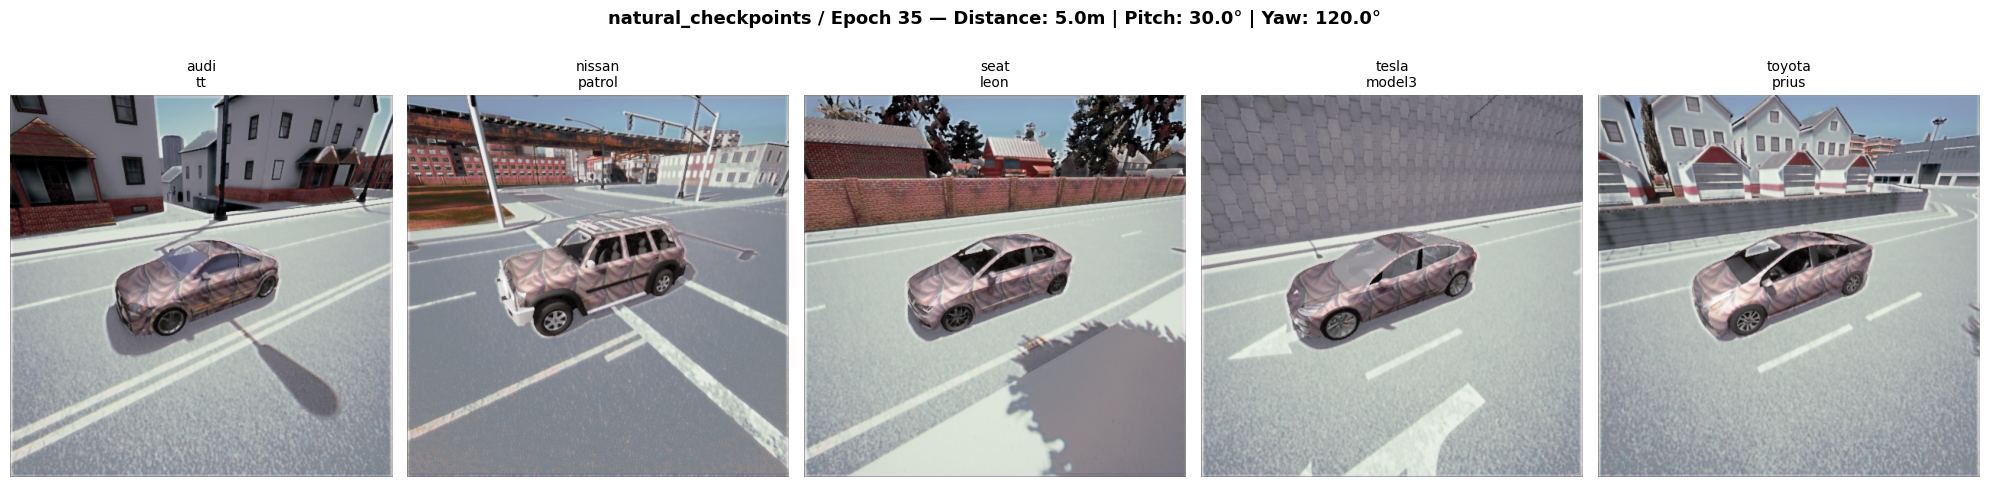

In [6]:
# Plot patched images of each vehicle type at a specific camera angle

TARGET_DISTANCE = 5.0
TARGET_PITCH    = 30.0
TARGET_YAW      = 120.0

PATCH_FOLDER = 'natural_checkpoints'
PATCH_EPOCH  = 35
TEX_RES_PLOT = 64 

ckpt_path = os.path.join(PATCH_FOLDER, f'patch_epoch_{PATCH_EPOCH}.png')
texture   = load_texture_from_png(ckpt_path, tex_res=TEX_RES_PLOT)

rows = []
for vehicle_id in sorted(df_all['vehicle_id'].unique()):
    match = df_all[
        (df_all['vehicle_id'] == vehicle_id) &
        (df_all['distance']   == TARGET_DISTANCE) &
        (df_all['pitch']      == TARGET_PITCH) &
        (df_all['yaw']        == TARGET_YAW)
    ]
    if len(match) > 0:
        rows.append(match.iloc[0])

fig, axes = plt.subplots(1, len(rows), figsize=(4 * len(rows), 5))
if len(rows) == 1:
    axes = [axes]

for ax, row in zip(axes, rows):
    fname       = row['filename']
    ref_img     = load_image(os.path.join(DATASET_FOLDER, 'reference', fname))
    mask_img    = load_image(os.path.join(DATASET_FOLDER, 'masks',     fname))
    overlay_img = load_image(os.path.join(DATASET_FOLDER, 'overlays',  fname))

    adv_img = apply_patch_to_sample(
        texture, ref_img, mask_img, overlay_img,
        tf.constant(row['distance'], dtype=tf.float32),
        tf.constant(row['pitch'],    dtype=tf.float32),
        tf.constant(row['yaw'],      dtype=tf.float32)
    )

    ax.imshow(adv_img.numpy())
    ax.set_title(row['vehicle_id'].replace('vehicle.', '').replace('.', '\n'), fontsize=10)
    ax.axis('off')

plt.suptitle(
    f"{PATCH_FOLDER} / Epoch {PATCH_EPOCH} — Distance: {TARGET_DISTANCE}m | Pitch: {TARGET_PITCH}° | Yaw: {TARGET_YAW}°",
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.show()

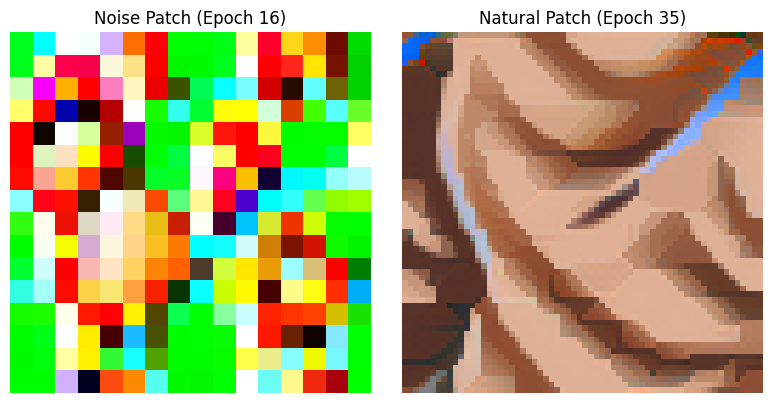

In [7]:
# plot noise epoch 16 next to natural epoch 35

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

img_noise = load_texture_from_png(os.path.join('noise_checkpoints', 'patch_epoch_16.png'), tex_res=16).numpy()
img_nat   = load_texture_from_png(os.path.join('natural_checkpoints', 'patch_epoch_35.png'), tex_res=TEX_RES).numpy()

axes[0].imshow(img_noise, interpolation='nearest')
axes[0].set_title('Noise Patch (Epoch 16)')
axes[0].axis('off')

axes[1].imshow(img_nat, interpolation='nearest')
axes[1].set_title('Natural Patch (Epoch 35)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

Generating Applied Top-vs-Bottom Comparison...


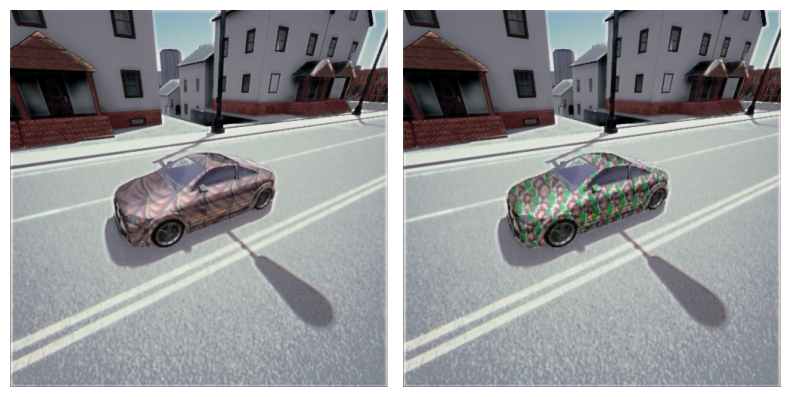

In [ ]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf


TARGET_DISTANCE = 5.0
TARGET_PITCH    = 30.0
TARGET_YAW      = 120.0
DATASET_FOLDER  = 'sample_dataset'


target_vehicle = 'vehicle.audi.tt'
match = df_all[
    (df_all['vehicle_id'] == target_vehicle) &
    (df_all['distance']   == TARGET_DISTANCE) &
    (df_all['pitch']      == TARGET_PITCH) &
    (df_all['yaw']        == TARGET_YAW)
]

if len(match) > 0:
    row = match.iloc[0]
    fname       = row['filename']
    ref_img     = load_image(os.path.join(DATASET_FOLDER, 'reference', fname))
    mask_img    = load_image(os.path.join(DATASET_FOLDER, 'masks',     fname))
    overlay_img = load_image(os.path.join(DATASET_FOLDER, 'overlays',  fname))

    adv_img_nat = apply_patch_to_sample(
        tex_natural, ref_img, mask_img, overlay_img,
        tf.constant(row['distance'], dtype=tf.float32),
        tf.constant(row['pitch'],    dtype=tf.float32),
        tf.constant(row['yaw'],      dtype=tf.float32)
    )

    tex_noise = load_texture_from_png(noise_ckpt, tex_res=16)
    adv_img_noise = apply_patch_to_sample(
        tex_noise, ref_img, mask_img, overlay_img,
        tf.constant(row['distance'], dtype=tf.float32),
        tf.constant(row['pitch'],    dtype=tf.float32),
        tf.constant(row['yaw'],      dtype=tf.float32)
    )

    fig, axes = plt.subplots(1, 2, figsize=(8, 10))

    axes[0].imshow(adv_img_nat.numpy())
    axes[0].axis('off')

    axes[1].imshow(adv_img_noise.numpy())
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No valid samples found.")